Name: Samin Thapa

ID: 2408644

# Implementation of MCP Neuron for AND and OR Function.

In [1]:
def MCP_Neurons_AND(X1, X2, T):
    """
    MCP Neuron implementing AND operation for two binary inputs.

    Parameters:
        X1 (list): Binary input array
        X2 (list): Binary input array
        T  (int) : Threshold value

    Returns:
        state_neuron (list): Output states (1 or 0)
    """
    assert len(X1) == len(X2)

    # Step 1: Element-wise addition of inputs
    sum_inputs = [X1[i] + X2[i] for i in range(len(X1))]

    # Step 2: Apply threshold
    state_neuron = []
    for element in sum_inputs:
        if element >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [2]:
# --- Test AND Gate ---
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2

result = MCP_Neurons_AND(X1, X2, T)

print(f"AND Gate (T={T})")
print(f"  Inputs:   X1={X1}, X2={X2}")
print(f"  Output:   {result}")
print(f"  Expected: [0, 0, 0, 1]")
print(f"  Match:    {result == [0, 0, 0, 1]}")

AND Gate (T=2)
  Inputs:   X1=[0, 0, 1, 1], X2=[0, 1, 0, 1]
  Output:   [0, 0, 0, 1]
  Expected: [0, 0, 0, 1]
  Match:    True


In [3]:
def MCP_Neurons_OR(X1, X2, T):
    """
    MCP Neuron implementing OR operation for two binary inputs.

    Parameters:
        X1 (list): Binary input array
        X2 (list): Binary input array
        T  (int) : Threshold value

    Returns:
        state_neuron (list): Output states (1 or 0)
    """
    assert len(X1) == len(X2)

    # Step 1: Element-wise addition of inputs
    sum_inputs = [X1[i] + X2[i] for i in range(len(X1))]

    # Step 2: Apply threshold
    state_neuron = []
    for element in sum_inputs:
        if element >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [4]:
# --- Test OR Gate ---
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1

result_or = MCP_Neurons_OR(X1, X2, T)

print(f"OR Gate (T={T})")
print(f"  Inputs:   X1={X1}, X2={X2}")
print(f"  Output:   {result_or}")
print(f"  Expected: [0, 1, 1, 1]")
print(f"  Match:    {result_or == [0, 1, 1, 1]}")

OR Gate (T=1)
  Inputs:   X1=[0, 0, 1, 1], X2=[0, 1, 0, 1]
  Output:   [0, 1, 1, 1]
  Expected: [0, 1, 1, 1]
  Match:    True


### Question 1: List out all the limitations of MCP Neurons.


1. **Only binary inputs**: MCP neurons can handle only 0 or 1. They are unable to handle continuous or real-valued information.

2. **No adjustable parameters**: Every input has an equal impact on the total. There is no system to allocate varying significance to different inputs.

3. **Static, hand-made threshold**: The threshold T has to be selected by the designer manually. There isn't a learning algorithm to automatically identify it.

4. **Inability to address non-linearly separable issues**: A single MCP neuron cannot represent functions such as XOR since the output categories cannot be divided by a single threshold on the total input.

5. **Absence of bias term**: The decision boundary exhibits restricted flexibility when there is no bias.

6. **Total inhibition**: A lone inhibitory input drives the output to 0, no matter how many excitatory inputs are active.

7. **Absence of learning system**: Each task requires the neuron to be set up manually


### Question 2: Can you solve XOR using a single MCP Neuron?


**No.** XOR is **not a linear separation.** The truth table demonstrates the reason:

| X1 | X2 | Sum | XOR |
|----|----|----|-----|
| 0  | 0  | 0  | 0   |
| 0  | 1  | 1  | 1   |
| 1  | 0  | 1  | 1   |
| 1  | 1  | 2  | 0   |

- If T=1: rows 1-3 succeed, but row 4 does not (sum=2 ≥ 1 → outputs 1, yet XOR anticipates 0)

- When T=2: row 4 is successful, but rows 2-3 do not succeed (sum=1 < 2 → outputs 0, while XOR requires 1)

**Solution:** Integrate several MCP neurons into a network:

```
XOR(X1, X2) = AND( OR(X1, X2), NAND(X1, X2) )
```


In [5]:
# --- XOR using a Network of MCP Neurons ---

def MCP_NAND(X1, X2):
    """NAND gate: output 0 only when both inputs are 1."""
    state_neuron = []
    for i in range(len(X1)):
        if X1[i] + X2[i] >= 2:
            state_neuron.append(0)
        else:
            state_neuron.append(1)
    return state_neuron


def MCP_XOR_Network(X1, X2):
    """XOR = AND( OR(X1,X2), NAND(X1,X2) )"""
    or_result   = MCP_Neurons_OR(X1, X2, T=1)       # Layer 1
    nand_result = MCP_NAND(X1, X2)                   # Layer 1
    xor_result  = MCP_Neurons_AND(or_result, nand_result, T=2)  # Layer 2
    return xor_result


# Test
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
result_xor = MCP_XOR_Network(X1, X2)

print(f"XOR via MCP Network")
print(f"  Output:   {result_xor}")
print(f"  Expected: [0, 1, 1, 0]")
print(f"  Match:    {result_xor == [0, 1, 1, 0]}")

XOR via MCP Network
  Output:   [0, 1, 1, 0]
  Expected: [0, 1, 1, 0]
  Match:    True


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Implementation for 0 Vs. 1 Classification.

## Step 1: Load the Dataset

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AI/Copy of mnist_0_and_1.csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


### Question 1: What does the shape of X represent?

X.shape is **(N, 784)** in which:

- **N** = count of images (samples) present in the dataset

- **784** = quantity of attributes for each image (28 × 28 pixels compressed into a one-dimensional array)

Every row represents a single flattened grayscale image, while each column corresponds to a pixel position.

### Question 2: What does the shape of y represent?

y.shape is **(N,)** — a 1D array with N elements. Each element is the class label (0 or 1) for the corresponding image in X.


### Viewing the Dataset.

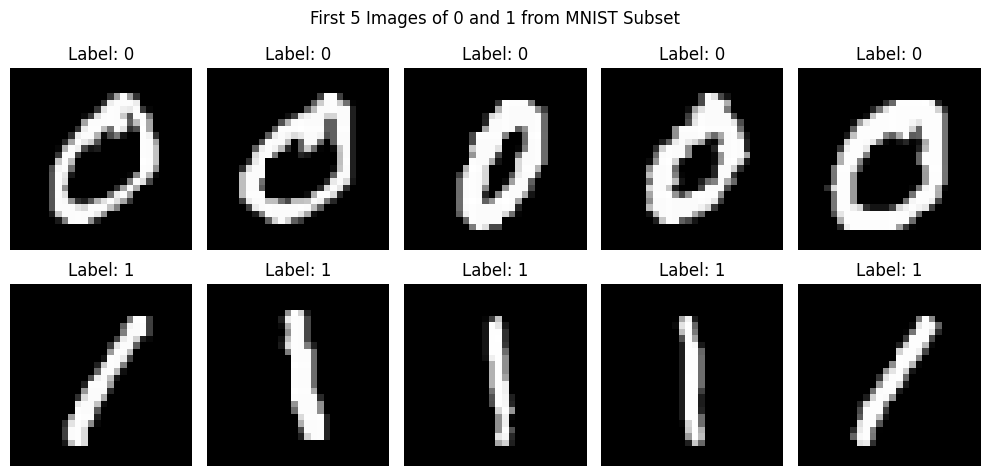

In [8]:
# Separate images by label
images_0 = X[y == 0]
images_1 = X[y == 1]

# Plot first 5 of each digit
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(5):
    axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 0")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 1")
    axes[1, i].axis("off")

plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
plt.tight_layout()
plt.show()

## Step - 2 - Initializing the Weights:

In [9]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

### Question 3: What does the weights array represent?

**Answer:**  
One weight per pixel in a **(784,)** 1D NumPy array. The significance of each pixel in differentiating between digits 0 and 1 is indicated by its weight. The perceptron learns to give discriminative pixels higher weights and irrelevant pixels almost zero weights during training.## Question

### Question 4: Why initialize weights to zero?

**Answer:**  
Zero initialization is appropriate for a **single-layer perceptron** because:
The symmetry-breaking problem (which only affects multi-layer networks with buried neurons) does not exist.
The initial incorrectly categorized sample initiates an update and begins to form the weight vector.
Regardless of initialization, the Perceptron Convergence Theorem ensures convergence for linearly separable data.


## Step - 3 - Make a Decision function:

In [10]:
def decision_function(X, weights, bias):
    """
    Predict labels using the trained perceptron.

    Parameters:
        X       : Feature matrix  (n_samples, n_features)
        weights : Weight vector    (n_features,)
        bias    : Bias scalar

    Returns:
        y_pred  : Predicted labels (n_samples,) — values are 0 or 1
    """
    # Weighted sum: z = X·w + b
    predictions = np.dot(X, weights) + bias

    # Step activation: 1 if z >= 0, else 0
    y_pred = np.where(predictions >= 0, 1, 0)

    return y_pred

## Step - 3 - Implement the Perceptron Learning Algorithm

In [11]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Rule.

    Parameters:
        X             : Feature matrix  (n_samples, n_features)
        y             : True labels      (n_samples,)
        weights       : Initial weights  (n_features,)
        bias          : Initial bias     (scalar)
        learning_rate : Step size for updates (default 0.1)
        epochs        : Number of passes over the dataset (default 100)

    Returns:
        weights  : Trained weights
        bias     : Trained bias
        accuracy : Final training accuracy
    """
    for epoch in range(epochs):
        for i in range(len(y)):
            # 1. Compute weighted sum
            linear_output = np.dot(X[i], weights) + bias

            # 2. Apply step activation
            y_pred = 1 if linear_output >= 0 else 0

            # 3. Compute error
            error = y[i] - y_pred

            # 4. Update weights and bias (only if prediction is wrong)
            weights = weights + learning_rate * error * X[i]
            bias    = bias    + learning_rate * error

    # Calculate final accuracy
    y_pred_all = decision_function(X, weights, bias)
    accuracy   = np.mean(y_pred_all == y)

    return weights, bias, accuracy

### Question 5: What is the purpose of `np.dot(X[i], weights) + bias`?

**Answer:**  
This computes the **weighted sum (net input):** z = Σ(w_j × x_j) + bias

- `np.dot(X[i], weights)` multiplies each of the 784 pixel values by its corresponding weight and sums them
- Adding `bias` shifts the decision boundary
- The result z is then passed through the step function to produce a binary prediction

### Question 6: What happens when the prediction is wrong?

**Answer:**  
The perceptron updates weights using: **Δw = η × (y_true − ŷ) × x**

Two cases:
- **False negative** (true=1, predicted=0): error = +1 → features are **added** to weights → neuron becomes more likely to fire for similar inputs
- **False positive** (true=0, predicted=1): error = -1 → features are **subtracted** from weights → neuron becomes less likely to fire

When prediction is correct, error = 0 and no update occurs.

### Question 7: Why is the final accuracy important?

**Answer:**  
It measures how well the perceptron classifies the training data. For **0 vs 1**, we expect **~100% accuracy** because:
- Digits 0 and 1 are visually very different (ring shape vs thin stroke)
- The classes are easily **linearly separable** in 784-D pixel space
- The Perceptron Convergence Theorem guarantees convergence on linearly separable data

## Training the Perceptron

In [ ]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

Epoch 10: Accuracy = 1.0000
Epoch 20: Accuracy = 1.0000
Epoch 30: Accuracy = 1.0000
Epoch 40: Accuracy = 1.0000
Epoch 50: Accuracy = 1.0000
Epoch 60: Accuracy = 1.0000
Epoch 70: Accuracy = 1.0000
Epoch 80: Accuracy = 1.0000
Epoch 90: Accuracy = 1.0000
Epoch 100: Accuracy = 1.0000
The Final Accuracy is:  1.0


## Step 5: Visualize Misclassified Images

In [ ]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


### Question 8: What does `misclassified_idx` store?

**Answer:**  
A NumPy array containing the **indices** of all samples where `y_pred != y`. For example, if `misclassified_idx = [42, 156]`, then samples 42 and 156 were incorrectly classified.

It is used to:
1. Check whether any errors exist (`len(misclassified_idx) > 0`)
2. Visualize up to 10 misclassified images with their predicted vs true labels

### Question 9: How do you interpret "All images were correctly classified!"?

**Answer:**  
It means the perceptron achieved **100% training accuracy** — every image was assigned the correct label. The data is **perfectly linearly separable**, and the perceptron found a hyperplane that separates all 0s from all 1s.

**Note:** 100% training accuracy does not guarantee 100% test accuracy on unseen data, but for such visually distinct digits, generalization should be excellent.

# Implementation for 3 Vs. 5 Classification.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AI/Copy of mnist_3_and_5.csv")

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (3 or 5)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


### Viewing the Dataset.

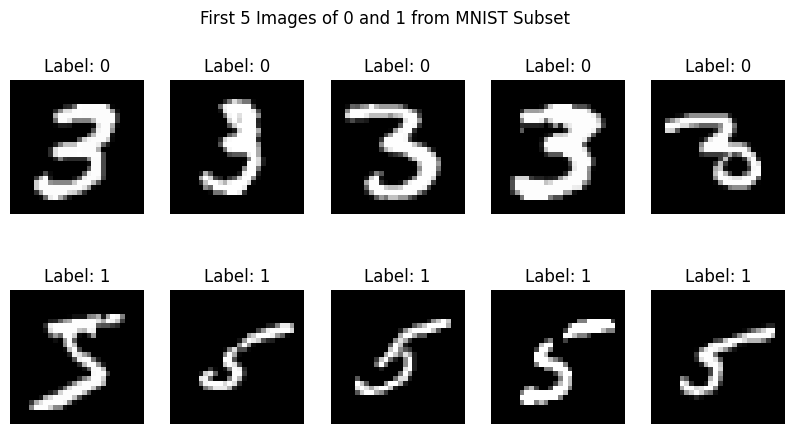

In [13]:
# Separate images for label 3 and label 5
images_3 = X[y == 3]  # Get all images with label 3
images_5 = X[y == 5]  # Get all images with label 5

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_3) < 5 or len(images_5) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

## Step - 2 - Initializing the Weights:

In [14]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

## Step - 3 - Implement the Perceptron Learning Algorithm

In [ ]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):

    # Convert labels: 5 → 1, 3 → 0
    y_binary = np.where(y == 5, 1, 0)

    for epoch in range(epochs):
        for i in range(len(X)):

            linear_output = np.dot(X[i], weights) + bias
            y_pred = 1 if linear_output >= 0 else 0

            # Update
            weights += learning_rate * (y_binary[i] - y_pred) * X[i]
            bias += learning_rate * (y_binary[i] - y_pred)

    # Accuracy
    correct = 0
    for i in range(len(X)):
        y_pred = 1 if (np.dot(X[i], weights) + bias) >= 0 else 0

        if y_pred == y_binary[i]:
            correct += 1

    accuracy = correct / len(X)

    return weights, bias, accuracy

## Training the Perceptron

In [ ]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

## Step 5: Visualize Misclassified Images

Final Accuracy: 0.4586


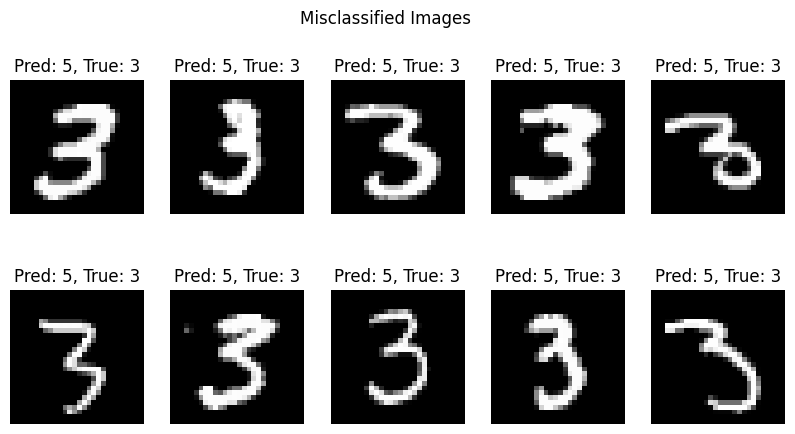

In [15]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 5, 3)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")